# Data Pull

This code will be used to pull EIA, Yfinance, and CFTC Data for Feature Engineering

In [1]:
import requests 
import pandas as pd
import numpy as np
import yfinance as yf

In [2]:
API_KEY = "o9qzkhQuQSHvYbe9siZln5TIFq8QYqB8iZNIGlO4"

Full List of Test Features

- Δ US Crude Stocks (EIA)
- Δ Cushing Stocks  (EIA)
- Refinery Utilization (EIA)
- Net Imports (EIA)
- 3-2-1 Crack Spread (EIA)
- WTI Spot-CL1 (EIA/Yfinance)
- DXY (Yfinance)
- BZ1-CL1 (Yfinance)
- CFTC Positioning (CFTC)


From yfinance, CL1, BZ1, DXY, RBOB, HO and crack spot pricing.

In [5]:
cl1 = yf.download('CL=F', start='2010-01-01', interval='1d')
cl1_weekly = cl1['Close'].resample('W-FRI').mean()
cl1_weekly.dropna(how = 'any', inplace = True)

BZ1 = yf.download('BZ=F', start='2010-01-01', interval='1d')
BZ1_weekly = BZ1['Close'].resample('W-FRI').mean()
BZ1_weekly.dropna(how = 'any', inplace = True)

ticker = "DX-Y.NYB"
dxy = yf.download(ticker, start="2010-01-01", interval="1d")
dxy = dxy['Close'].resample('W-FRI').mean()

STEO_df = pd.concat([cl1_weekly, BZ1_weekly, dxy], axis=1, join="inner")
STEO_df = STEO_df.apply(pd.to_numeric, errors = "coerce")

STEO_df['BZ1-CL1'] = STEO_df['BZ=F'] - STEO_df['CL=F']

print(STEO_df.tail())

/var/folders/35/hrwsw7d52qq2px4199wv4w3m0000gn/T/ipykernel_38773/2960944377.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  cl1 = yf.download('CL=F', start='2010-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed
/var/folders/35/hrwsw7d52qq2px4199wv4w3m0000gn/T/ipykernel_38773/2960944377.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  BZ1 = yf.download('BZ=F', start='2010-01-01', interval='1d')
[*********************100%***********************]  1 of 1 completed
/var/folders/35/hrwsw7d52qq2px4199wv4w3m0000gn/T/ipykernel_38773/2960944377.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dxy = yf.download(ticker, start="2010-01-01", interval="1d")
[*********************100%***********************]  1 of 1 completed

Ticker            CL=F        BZ=F    DX-Y.NYB   BZ1-CL1
Date                                                    
2026-04-03  103.980000  110.330000  100.037500  6.350000
2026-04-10  102.842001  100.981998   99.244000 -1.860004
2026-04-17   92.038000   95.770000   98.174001  3.731999
2026-04-24   92.989999  101.254002   98.472002  8.264003
2026-05-01   97.985001  106.060001   98.568501  8.075001


In [6]:
import yfinance as yf
import pandas as pd

# Download adjusted closes for all 3 tickers
df_321 = yf.download(["CL=F", "RB=F", "HO=F"], start="2010-01-01")["Close"]

# Rename for clarity
df_321.columns = ["Cl1", "RBOB", "HO"]

# Convert to $/bbl
df_321["RBOB_bbl"] = df_321["RBOB"] * 42
df_321["HO_bbl"]   = df_321["HO"] * 42

# Crack spread
df_321["321_Crack"] = ((2 * df_321["RBOB_bbl"] + df_321["HO_bbl"]) / 3) - df_321["Cl1"]

df_321.dropna(how = 'any', inplace = True)

df_321 = df_321.resample("W-FRI").mean()

print(df_321.tail())

/var/folders/35/hrwsw7d52qq2px4199wv4w3m0000gn/T/ipykernel_38773/1966528269.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_321 = yf.download(["CL=F", "RB=F", "HO=F"], start="2010-01-01")["Close"]
[*********************100%***********************]  3 of 3 completed

                   Cl1     RBOB       HO    RBOB_bbl      HO_bbl  321_Crack
Date                                                                       
2026-04-03  103.980000  4.23640  3.26080  177.928800  136.953600  60.290401
2026-04-10  102.842001  4.06256  3.13146  170.627519  131.521320  54.750118
2026-04-17   92.038000  3.68838  3.07864  154.911960  129.302881  54.337600
2026-04-24   92.989999  3.81664  3.32184  160.298880  139.517280  60.381680
2026-05-01   97.985001  3.90835  3.44405  164.150700  144.650098  59.665498


In [43]:
# Calculated 321 Crack Spread

In [7]:
df_321 = df_321[['321_Crack']]
print(df_321.head())

            321_Crack
Date                 
2010-01-08   8.904879
2010-01-15   8.103960
2010-01-22   7.330599
2010-01-29   7.274360
2010-02-05   7.881117


Pulled and aligned on weekly frequency DXY, CL1 and BZ1 dating back to 2010. and calculated BZ1-CL1 spread(relevant predictor)

Now pulling from EIA API for inventory and spot data

In [9]:
API_KEY = API_KEY

def fetch_eia_data(
    endpoint,
    facet_name,
    facet_value,
    start,
    end,
    frequency,
    column_name=None,
    sort_direction="asc",
    length=5000
):
    url = (
        f"https://api.eia.gov/v2/{endpoint}/data/"
        f"?api_key={API_KEY}"
        f"&frequency={frequency}"
        f"&data[0]=value"
        f"&facets[{facet_name}][]={facet_value}"
        f"&start={start}"
        f"&end={end}"
        f"&sort[0][column]=period"
        f"&sort[0][direction]={sort_direction}"
        f"&offset=0"
        f"&length={length}"
    )

    r = requests.get(url)
    r.raise_for_status()
    js = r.json()

    df = pd.DataFrame(js["response"]["data"])
    df["date"] = pd.to_datetime(df["period"])

    if column_name is None:
        column_name = facet_value

    df = df.rename(columns={"value": column_name})
    return df.set_index("date")[[column_name]].sort_index()

In [10]:
brent = fetch_eia_data(
    endpoint="petroleum/pri/spt",
    facet_name="product",
    facet_value="EPCBRENT",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="Brent_Spot",
    sort_direction="desc",
    length=6000
)

wti = fetch_eia_data(
    endpoint="petroleum/pri/spt",
    facet_name="product",
    facet_value="EPCWTI",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="WTI_Spot",
    sort_direction="desc",
    length=6000
)

us_netimport = fetch_eia_data(
    endpoint="petroleum/move/wkly",
    facet_name="series",
    facet_value="WTTNTUS2",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="US_Net_Imports",
    sort_direction="desc",
    length=6000

)

us_stocks = fetch_eia_data(
    endpoint="petroleum/stoc/wstk",
    facet_name="series",
    facet_value="WCESTUS1",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="US_Stocks",
    sort_direction="desc", 
    length=6000
)

cushing_stocks = fetch_eia_data(
    endpoint="petroleum/stoc/wstk",
    facet_name="series",
    facet_value="W_EPC0_SAX_YCUOK_MBBL",
    start="2010-01", 
    end="2026-06", 
    frequency="weekly",
    column_name="Cushing_Stocks",
    sort_direction="desc",
    length=6000
    
) 

ref_util = fetch_eia_data(
    endpoint="petroleum/pnp/wiup",
    facet_name="series", 
    facet_value="WPULEUS3",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="Prcnt_US_Ref_Utlzn",
    sort_direction="desc", 
    length=6000
) 

disti_stocks = fetch_eia_data(
    endpoint="petroleum/stoc/wstk",
    facet_name="series",
    facet_value="WDIST1A1",
    start="2010-01", 
    end="2026-06", 
    frequency="weekly",
    column_name="disti_stocks",
    sort_direction="desc",
    length=6000

) 

gas_stocks = fetch_eia_data(
    endpoint="petroleum/stoc/wstk",
    facet_name="series",
    facet_value="WGTSTUS1",
    start="2010-01", 
    end="2026-06", 
    frequency="weekly",
    column_name="gas_stocks",
    sort_direction="desc",
    length=6000

) 


balances_df = pd.concat([ref_util, cushing_stocks, us_stocks, us_netimport, brent, wti, gas_stocks, disti_stocks], axis=1, join="inner")
balances_df = balances_df.apply(pd.to_numeric, errors = "coerce")
balances_df["Chng_CushingStocks"] = balances_df["Cushing_Stocks"].diff()
balances_df["Chng_USstocks"] = balances_df["US_Stocks"].diff()
balances_df["Chng_WTI_Spot"] = balances_df["WTI_Spot"].diff()
balances_df["Chng_Gas_Stocks"] = balances_df["gas_stocks"].diff()
balances_df["Chng_Dist_Stocks"] = balances_df["disti_stocks"].diff()


balances_df.dropna(how = "any", inplace = True)

df_physical = balances_df
df_physical = df_physical.drop(columns=['Cushing_Stocks', 'US_Stocks', 'gas_stocks', 'disti_stocks'])

print(df_physical.tail())

            Prcnt_US_Ref_Utlzn  US_Net_Imports  Brent_Spot  WTI_Spot  \
date                                                                   
2026-03-20                92.9           -2953      111.40     96.07   
2026-03-27                92.1           -3323      111.24     94.29   
2026-04-03                92.0           -3518      123.94    105.67   
2026-04-10                89.6           -6024      124.61    104.54   
2026-04-17                89.1           -5103      114.43     93.84   

            Chng_CushingStocks  Chng_USstocks  Chng_WTI_Spot  Chng_Gas_Stocks  \
date                                                                            
2026-03-20              3421.0         6926.0           4.22          -2593.0   
2026-03-27               520.0         5451.0          -1.78           -586.0   
2026-04-03                24.0         3081.0          11.38          -1589.0   
2026-04-10             -1727.0         -913.0          -1.13          -6328.0   
2026-04-1

In [11]:
brent = fetch_eia_data(
    endpoint="petroleum/pri/spt",
    facet_name="product",
    facet_value="EPCBRENT",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="Brent_Spot",
    sort_direction="desc",
    length=6000
)

wti = fetch_eia_data(
    endpoint="petroleum/pri/spt",
    facet_name="product",
    facet_value="EPCWTI",
    start="2010-01",
    end="2026-06",
    frequency="weekly",
    column_name="WTI_Spot",
    sort_direction="desc",
    length=6000
)
cushing_stocks = fetch_eia_data(
    endpoint="petroleum/stoc/wstk",
    facet_name="series",
    facet_value="W_EPC0_SAX_YCUOK_MBBL",
    start="2010-01", 
    end="2026-06", 
    frequency="weekly",
    column_name="Cushing_Stocks",
    sort_direction="desc",
    length=6000
    
) 

balances_df = pd.concat([cushing_stocks, brent, wti], axis=1, join="inner")
balances_df = balances_df.apply(pd.to_numeric, errors = "coerce")
balances_df["Chng_CushingStocks"] = balances_df["Cushing_Stocks"].diff()
balances_df["Chng_WTI_Spot"] = balances_df["WTI_Spot"].diff()


print(balances_df.tail())

            Cushing_Stocks  Brent_Spot  WTI_Spot  Chng_CushingStocks  \
date                                                                   
2026-03-20           30945      111.40     96.07              3421.0   
2026-03-27           31465      111.24     94.29               520.0   
2026-04-03           31489      123.94    105.67                24.0   
2026-04-10           29762      124.61    104.54             -1727.0   
2026-04-17           30568      114.43     93.84               806.0   

            Chng_WTI_Spot  
date                       
2026-03-20           4.22  
2026-03-27          -1.78  
2026-04-03          11.38  
2026-04-10          -1.13  
2026-04-17         -10.70  


<Axes: xlabel='date'>

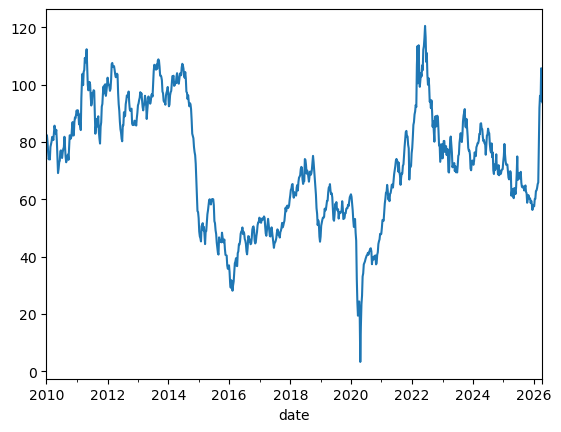

In [12]:
balances_df = balances_df.apply(pd.to_numeric, errors = "coerce")
balances_df['WTI_Spot'].plot()

we have to see if there is a more frequently released production number. US field production has a 2 month lag.

We choose to eliminate us field production as a feature. Net imports and change in stocks serve as more effective indicator for the same end. We also see incrimental and linear change in production week to week. Lacking in predictive power.

We are going to leave out metals index to mitigate noise. We believe we have sufficient demand proxy with other features. 

Finally lets add MM positioning data from CFTC.

CFTC Data Pulled. We are all good. Lets just concat into one data frame.

In [18]:
import pandas as pd
import requests
import zipfile
import io


years = list(range(2014, 2027))

dfs = []

for year in years:
    url = f"https://www.cftc.gov/files/dea/history/fut_disagg_txt_{year}.zip"
    try:
        response = requests.get(url)
        response.raise_for_status()

        z = zipfile.ZipFile(io.BytesIO(response.content))
        filename = z.namelist()[0]

        df_year = pd.read_csv(z.open(filename), low_memory=False)
        dfs.append(df_year)
        print(f"Pulled {year}")

    except Exception as e:
        print(f"Could not pull {year}: {str(e)}")


cot_all = pd.concat(dfs, ignore_index=True)
print("Concatenated all files — total obs:", len(cot_all))


cot_all["Report_Date"] = pd.to_datetime(
    cot_all["Report_Date_as_YYYY-MM-DD"], errors="coerce"
)

print("Latest available raw date:",
      cot_all["Report_Date"].max())

# ==============================
# CLEAN WTI FILTER (ROBUST)
# ==============================

wti = cot_all[
    (cot_all["CFTC_Contract_Market_Code"] == '067651') &
    (cot_all["FutOnly_or_Combined"] == "FutOnly")
].copy()

print("Filtered WTI Futures-Only dataset — total obs:", len(wti))

# ==============================
# Managed Money Columns
# ==============================

long_col  = "M_Money_Positions_Long_All"
short_col = "M_Money_Positions_Short_All"

# Net length and percent open interest
wti["MM_Net"] = wti[long_col] - wti[short_col]
wti["MM_pct_OI"] = wti["MM_Net"] / wti["Open_Interest_All"]


wti = wti.set_index("Report_Date").sort_index()
wti = wti.apply(pd.to_numeric, errors = "coerce")
wti= wti.resample("W-FRI").mean()


print(wti[["MM_Net", "MM_pct_OI"]].head())
print("Final Date range:", wti.index.min(), "to", wti.index.max())

Pulled 2014
Pulled 2015
Pulled 2016
Pulled 2017
Pulled 2018
Pulled 2019
Pulled 2020
Pulled 2021
Pulled 2022
Pulled 2023
Pulled 2024
Pulled 2025
Pulled 2026
Concatenated all files — total obs: 139673
Latest available raw date: 2026-04-21 00:00:00
Filtered WTI Futures-Only dataset — total obs: 590
               MM_Net  MM_pct_OI
Report_Date                     
2015-01-09   188251.0   0.125075
2015-01-16   204795.0   0.125831
2015-01-23   205706.0   0.129292
2015-01-30   203744.0   0.122145
2015-02-06   193444.0   0.112371
Final Date range: 2015-01-09 00:00:00 to 2026-04-24 00:00:00


In [19]:
wti = wti[['MM_Net', 'MM_pct_OI']]
wti["Change_MM_Net"] = wti["MM_Net"].diff()
wti.dropna(how = 'any', inplace = True)
print(wti.tail())

              MM_Net  MM_pct_OI  Change_MM_Net
Report_Date                                   
2026-03-27   94336.0   0.047119        -2035.0
2026-04-03   73347.0   0.036114       -20989.0
2026-04-10   78700.0   0.038619         5353.0
2026-04-17   98368.0   0.046965        19668.0
2026-04-24   99887.0   0.050327         1519.0


Now creating full dataset

In [20]:
df_full = pd.concat([wti,df_physical,STEO_df,df_321], axis = 1, join = "inner")
df_full = df_full.apply(pd.to_numeric, errors = "coerce")
df_full['Spot-Cl1'] = df_full['WTI_Spot'] - df_full['CL=F'] 
df_full

,MM_Net,MM_pct_OI,Change_MM_Net,Prcnt_US_Ref_Utlzn,US_Net_Imports,Brent_Spot,WTI_Spot,Chng_CushingStocks,Chng_USstocks,Chng_WTI_Spot,Chng_Gas_Stocks,Chng_Dist_Stocks,CL=F,BZ=F,DX-Y.NYB,BZ1-CL1,321_Crack,Spot-Cl1
2015-01-16,204795.0,0.125831,16544.0,85.5,5608,46.58,47.07,2909.0,10071.0,-1.70,588.0,-106.0,47.075999,47.613999,92.264000,0.538000,17.364040,-0.005999
2015-01-23,205706.0,0.129292,911.0,88.0,5749,46.44,46.46,2085.0,8874.0,-0.61,-2587.0,52.0,46.517500,48.582500,93.797501,2.065001,17.995201,-0.057500
2015-01-30,203744.0,0.122145,-1962.0,89.9,5371,46.76,45.32,2516.0,6333.0,-1.14,2335.0,-404.0,45.720000,49.670000,94.574001,3.950000,19.404920,-0.400000
2015-02-06,193444.0,0.112371,-10300.0,90.0,5106,54.62,50.58,1214.0,4327.0,5.26,1977.0,-902.0,50.648000,56.238000,94.297998,5.590000,21.431561,-0.068000
2015-02-13,195046.0,0.113558,1602.0,88.7,4955,56.57,51.14,3663.0,7716.0,0.56,485.0,-82.0,51.142000,56.774000,94.497998,5.632000,23.632000,-0.002000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20,96371.0,0.046297,4249.0,92.9,-2953,111.40,96.07,3421.0,6926.0,4.22,-2593.0,-163.0,96.098000,106.370000,99.652000,10.272000,65.289801,-0.028000
2026-03-27,94336.0,0.047119,-2035.0,92.1,-3323,111.24,94.29,520.0,5451.0,-1.78,-586.0,-40.0,92.984000,105.446001,99.606000,12.462001,68.743442,1.306000
2026-04-03,73347.0,0.036114,-20989.0,92.0,-3518,123.94,105.67,24.0,3081.0,11.38,-1589.0,-101.0,103.980000,110.330000,100.037500,6.350000,60.290401,1.690000
2026-04-10,78700.0,0.038619,5353.0,89.6,-6024,124.61,104.54,-1727.0,-913.0,-1.13,-6328.0,273.0,102.842001,100.981998,99.244000,-1.860004,54.750118,1.697999


In [21]:
df_full.shape

(588, 18)

In [22]:
df_full.to_pickle('oil_model_dataset.pkl')

df = pd.read_pickle('oil_model_dataset.pkl')
- to load into next notebook